In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone

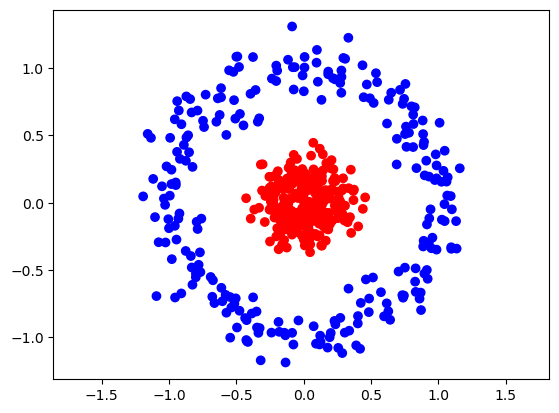

In [2]:
from sklearn.datasets import make_moons, make_circles
import matplotlib.colors as colors
import matplotlib.pyplot as plt
X, y = make_circles(n_samples=500, noise=0.1, random_state=42, factor=0.2)
y = 2 * y - 1
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
plt.scatter(X[:,0], X[:,1], c=y, cmap=colors.ListedColormap(["blue", "red"]))
plt.axis('equal')
plt.show()

TASK 1

In [5]:
class AdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, weak_classifier, n_classifiers=50, eta=0.5):
        self.weak_classifier = weak_classifier
        self.n_classifiers = n_classifiers
        self.eta = eta
        self.classifiers = []
        self.alphas = []

    def fit(self, X, y, plot_progress=False):
        n_samples = len(y)
        w = np.ones(n_samples) / n_samples  
        self.classifiers = []
        self.alphas = []

        for t in range(self.n_classifiers):
            clf = self.weak_classifier()  
            clf.fit(X, y, sample_weight=w) 
            y_pred = clf.predict(X)
            misclassified = (y_pred != y)
            epsilon = np.dot(w, misclassified) / np.sum(w)

            alpha = self.eta * np.log((1 - epsilon) / (epsilon + 1e-10))

            w = w * np.exp(alpha * misclassified) / np.sum(w) 

            self.classifiers.append(clf)
            self.alphas.append(alpha)

            if plot_progress:
                self.plot_iteration(X, y, t+1)

    def predict(self, X):
        final_pred = sum(alpha * clf.predict(X) for clf, alpha in zip(self.classifiers, self.alphas))
        return np.sign(final_pred)
    

    def plot_iteration(self, X, y, iteration):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.contourf(xx, yy, Z, alpha=0.8, cmap=colors.ListedColormap(['#FFAAAA', '#AAAAFF']))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=colors.ListedColormap(['blue', 'red']), edgecolor='k')
        plt.title(f"Iteration {iteration} - Classifier Fit")
        plt.axis('equal')
        plt.show()



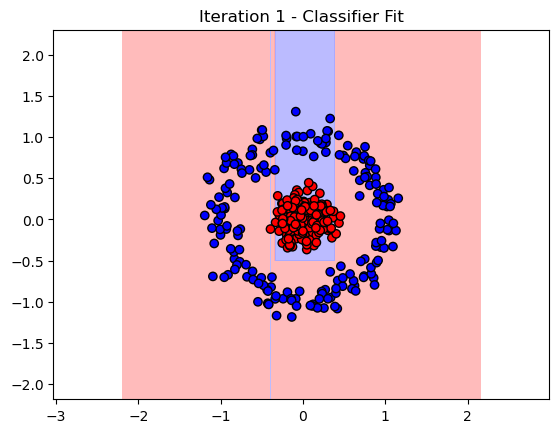

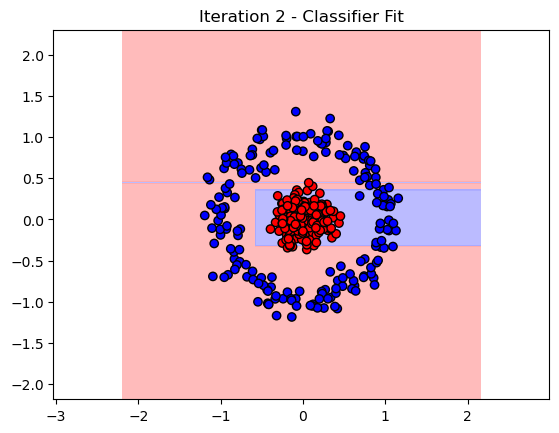

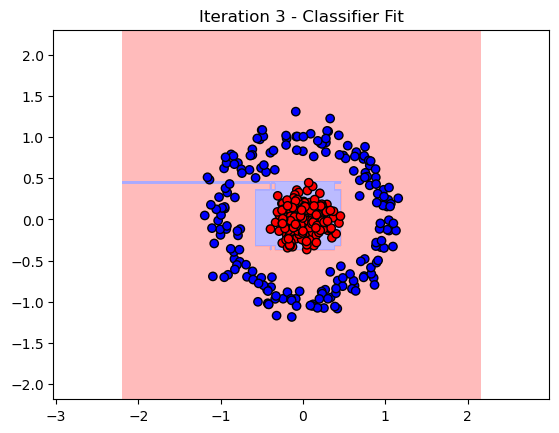

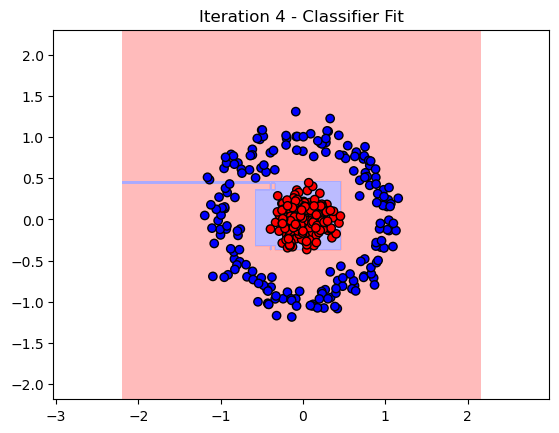

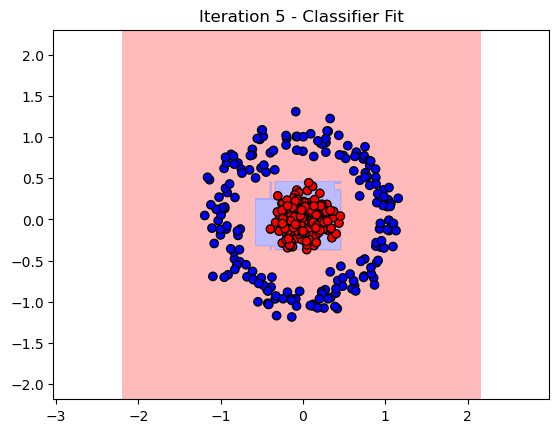

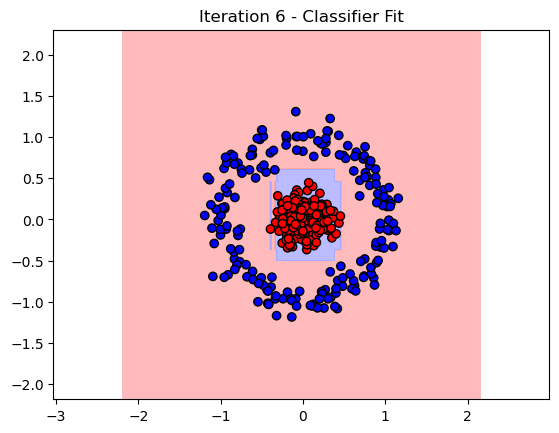

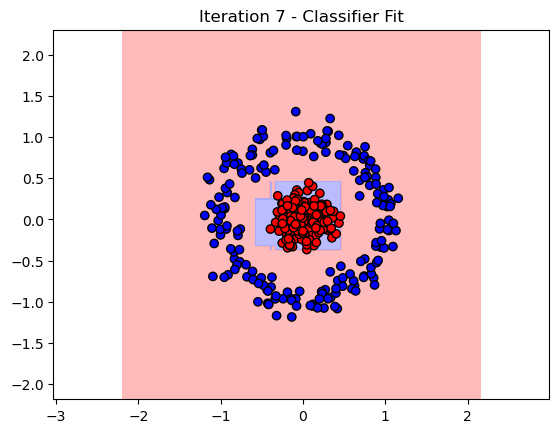

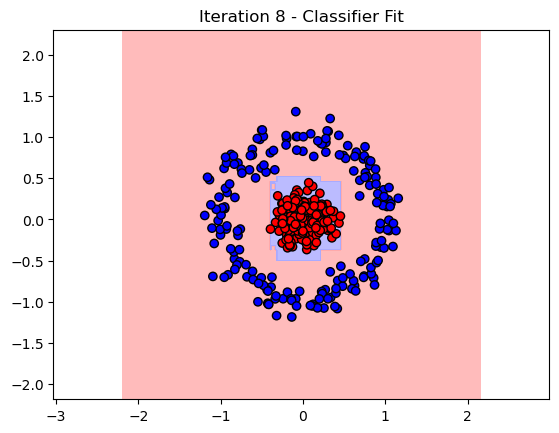

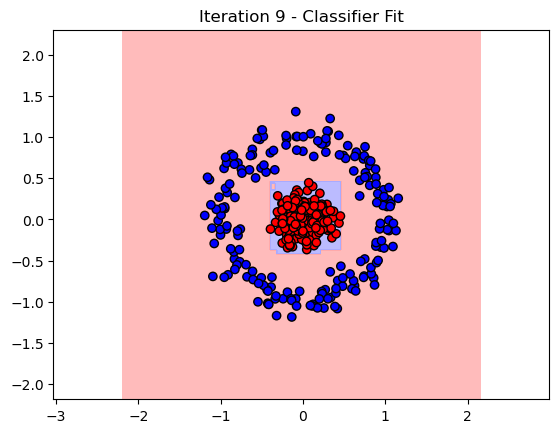

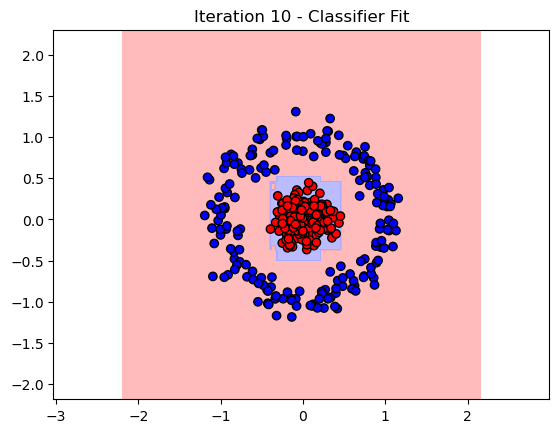

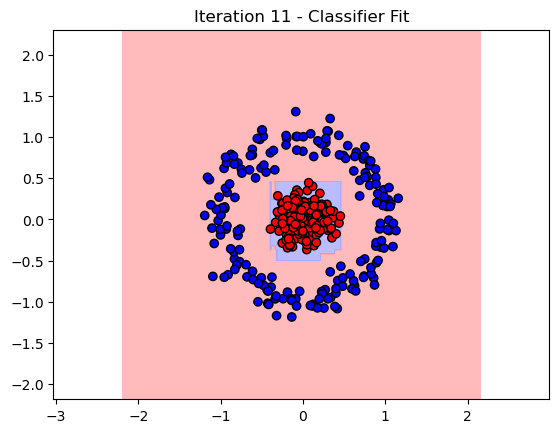

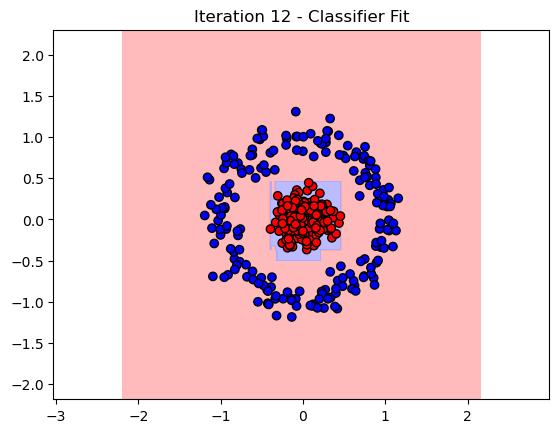

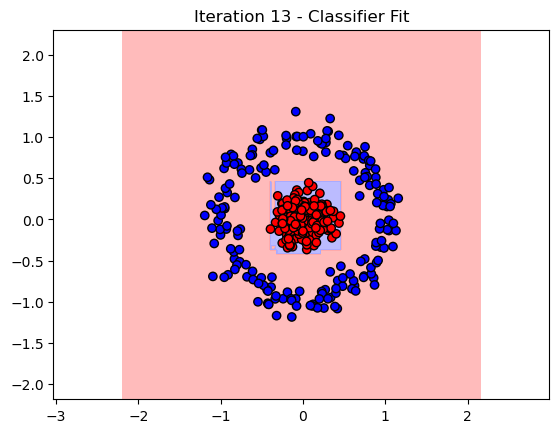

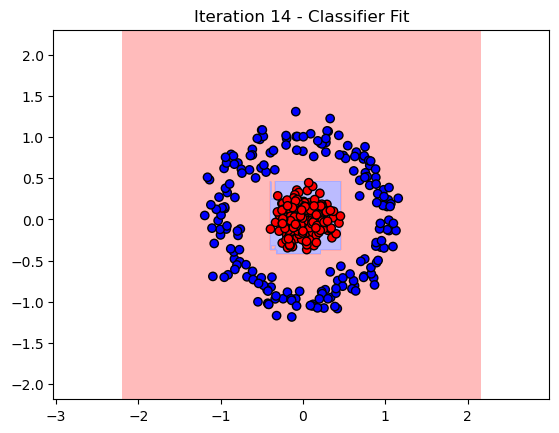

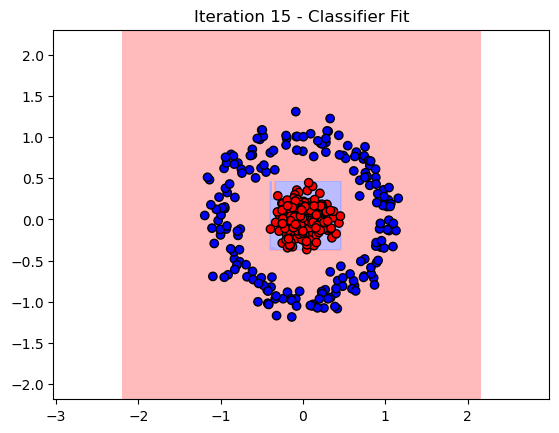

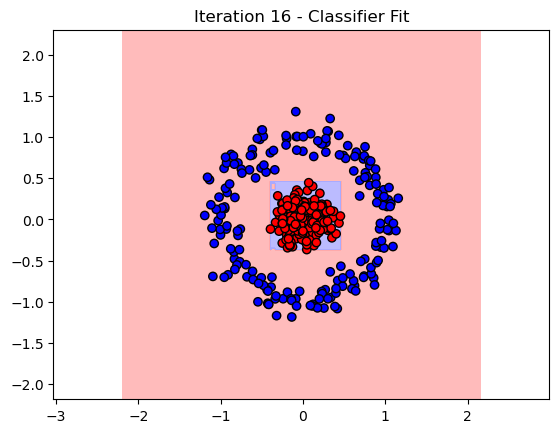

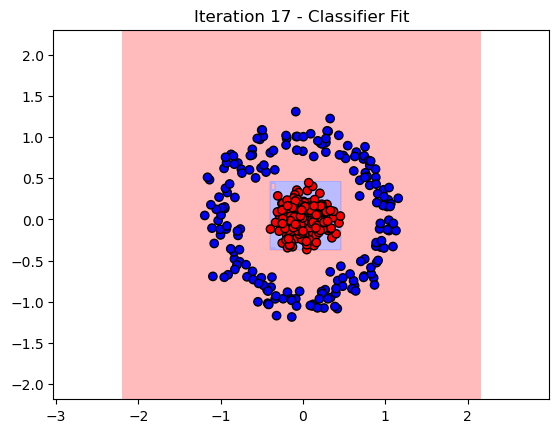

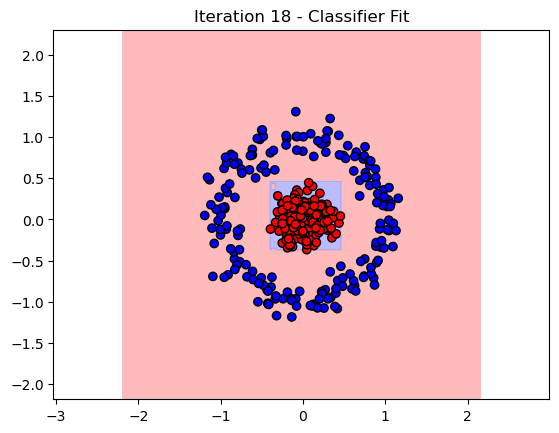

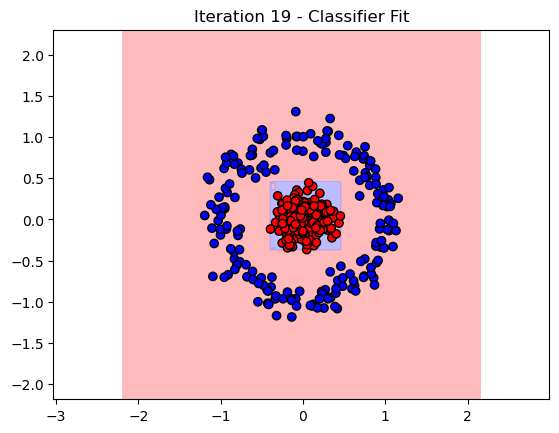

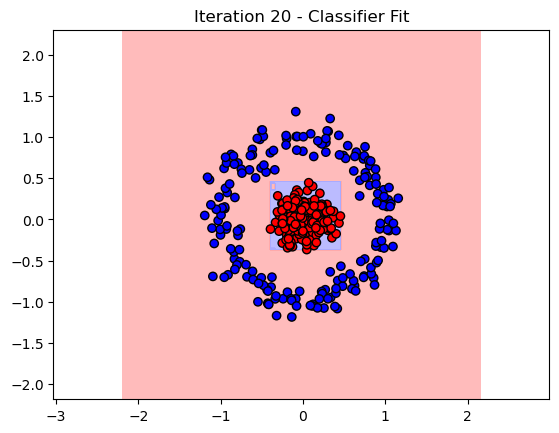

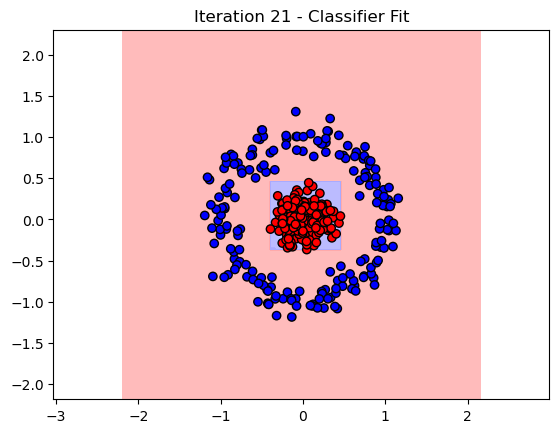

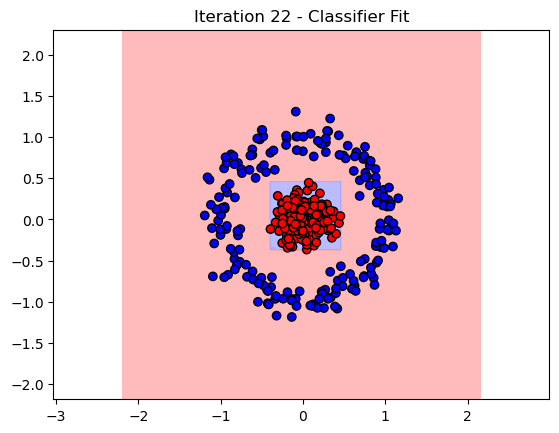

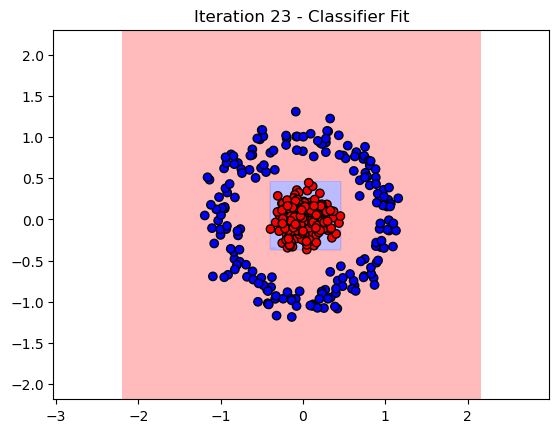

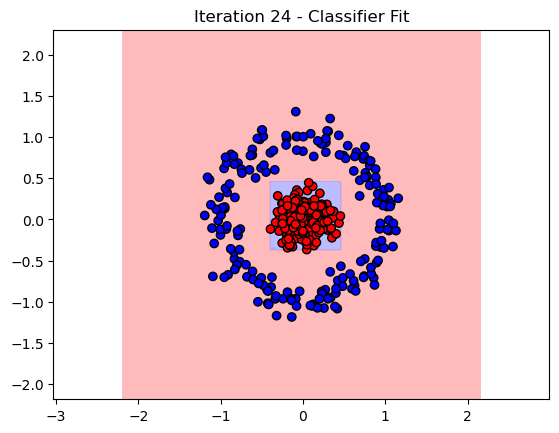

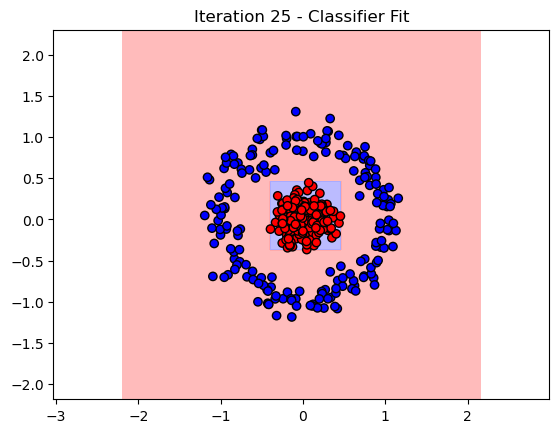

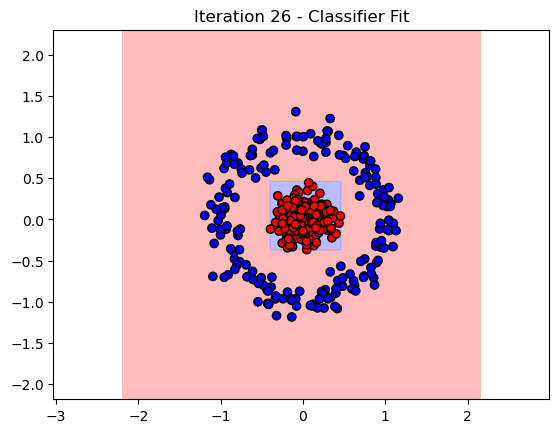

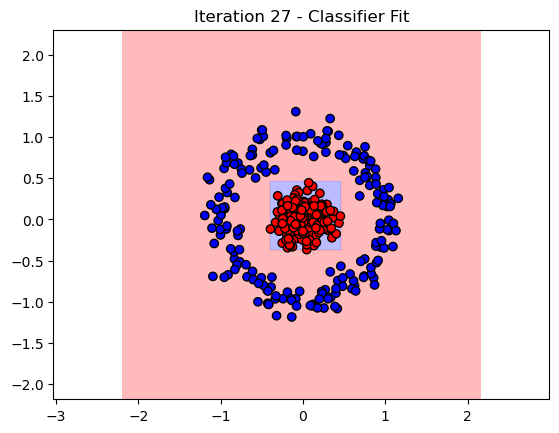

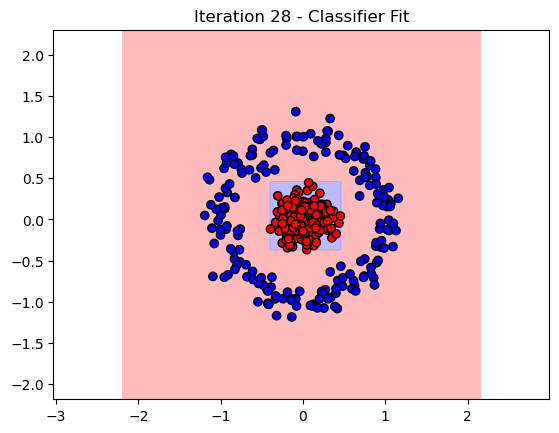

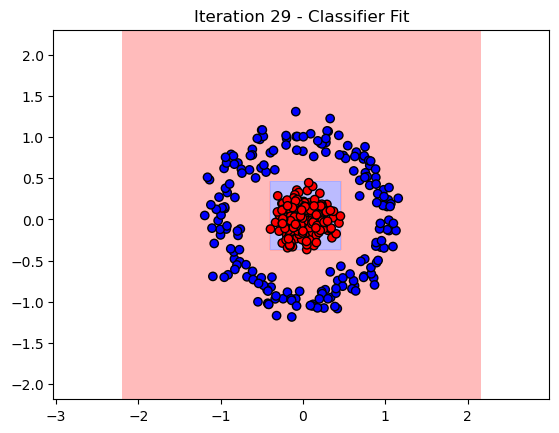

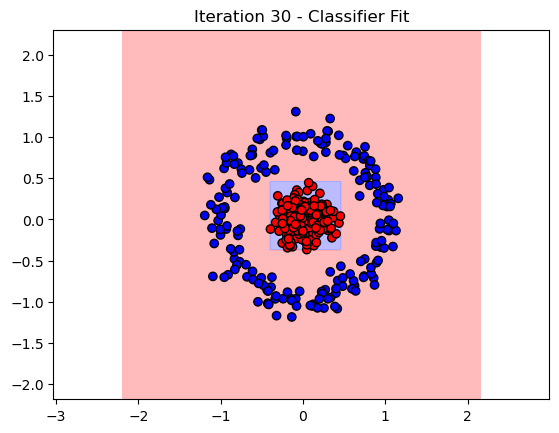

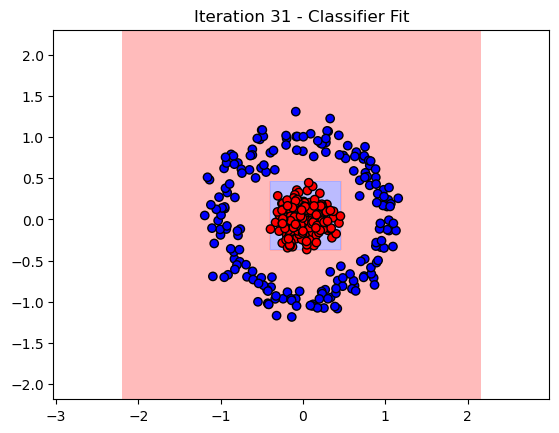

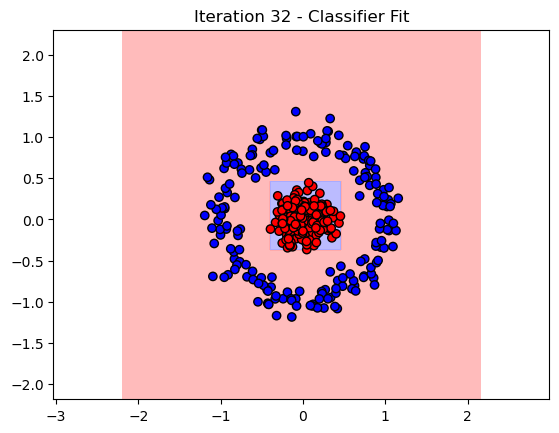

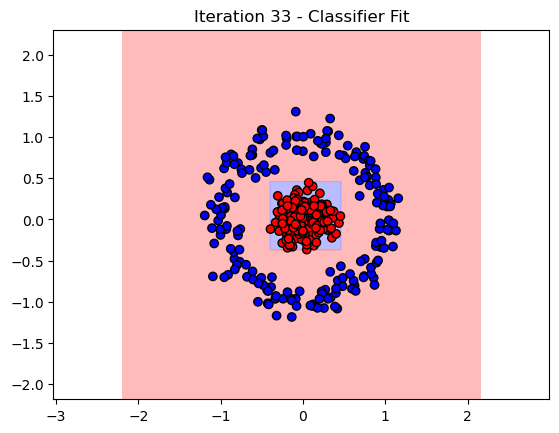

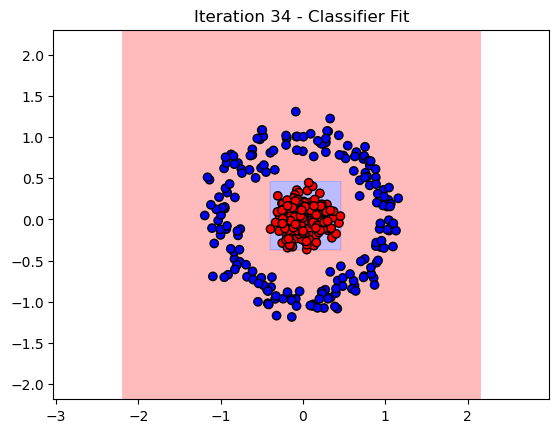

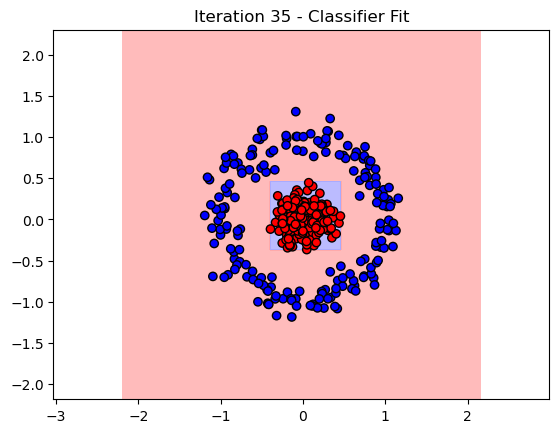

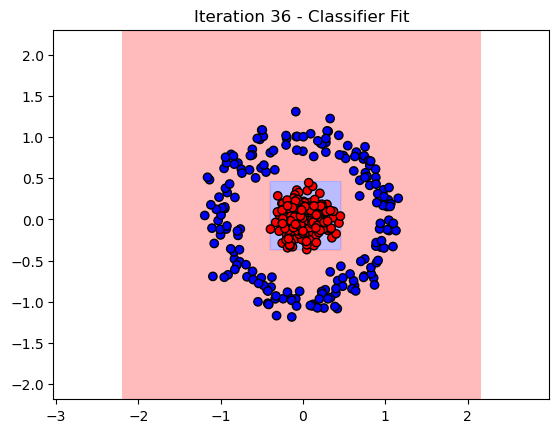

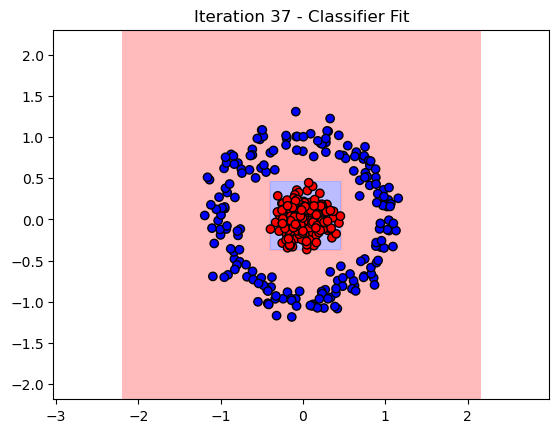

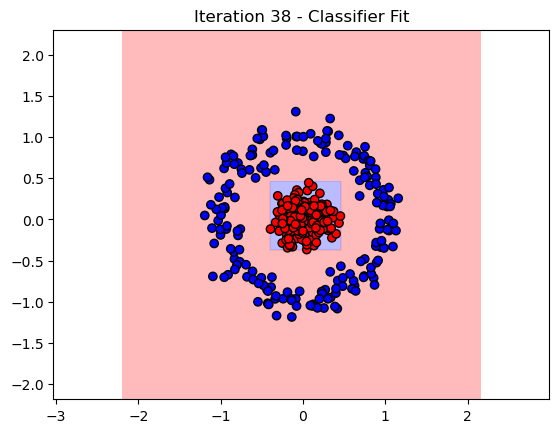

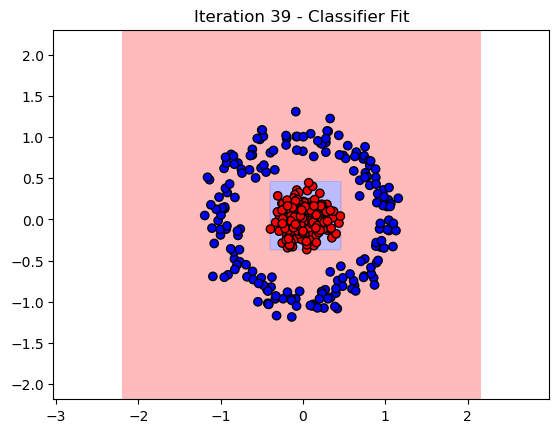

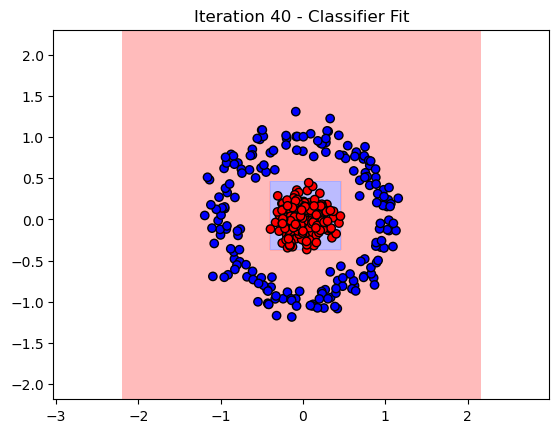

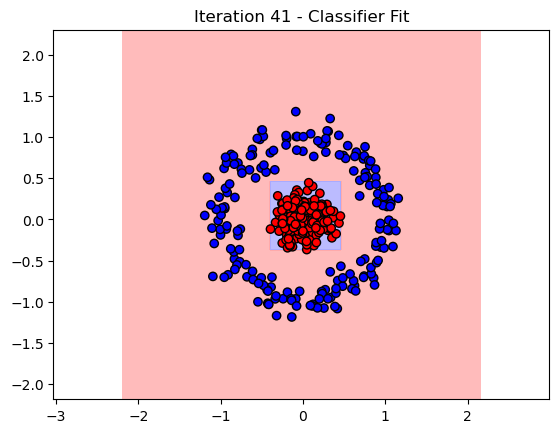

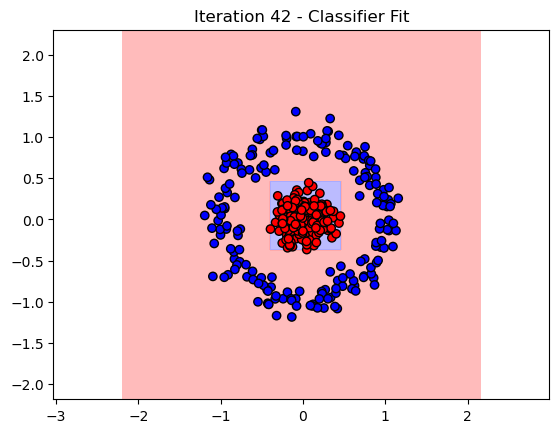

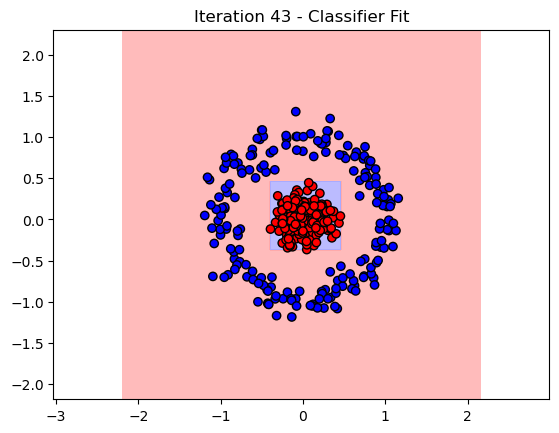

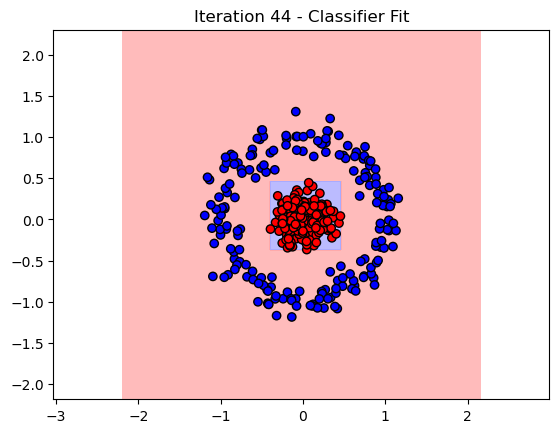

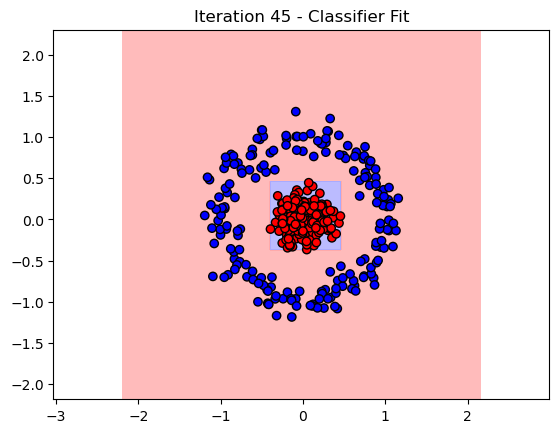

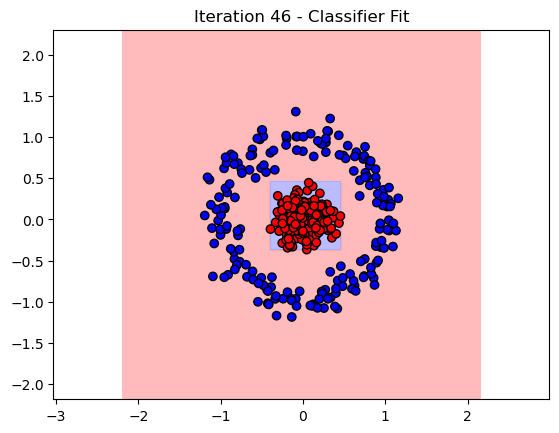

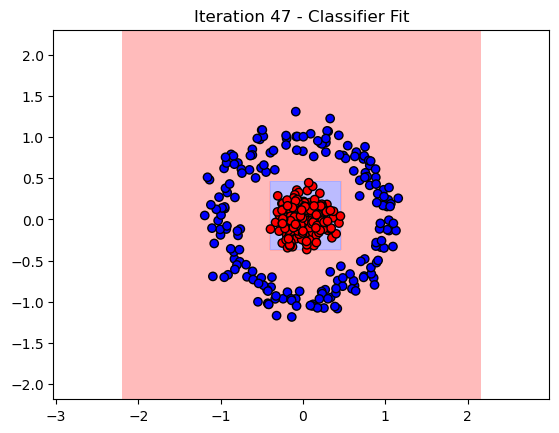

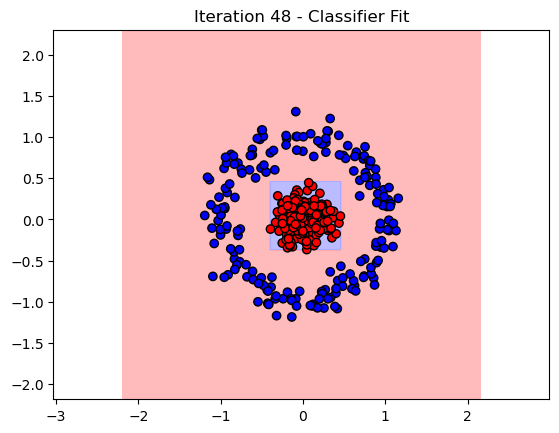

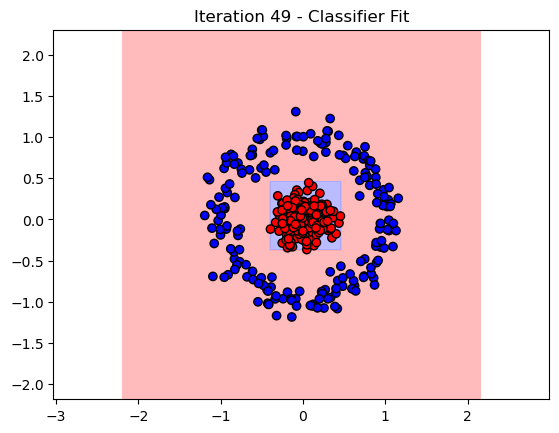

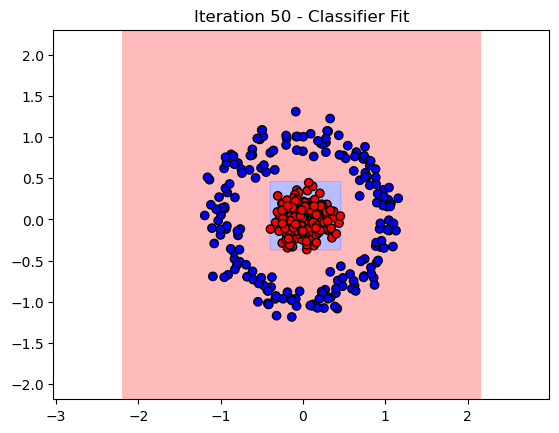

In [8]:
ada = AdaBoost(weak_classifier=lambda: DecisionTreeClassifier(max_depth=3), n_classifiers=50, eta=0.5)
ada.fit(X_train, y_train, plot_progress=True)


TASK 2

In [9]:
class AdaBoost(BaseEstimator, ClassifierMixin):
    def __init__(self, weak_classifier, n_classifiers=50, eta=0.5):
        self.weak_classifier = weak_classifier
        self.n_classifiers = n_classifiers
        self.eta = eta
        self.classifiers = []
        self.alphas = []

    def fit(self, X, y):
        n_samples = len(y)
        w = np.ones(n_samples) / n_samples  
        self.classifiers = []
        self.alphas = []

        for t in range(self.n_classifiers):
            clf = clone(self.weak_classifier)  # Clone the weak classifier
            try:
                clf.fit(X, y, sample_weight=w)  # Try fitting with sample weights
            except TypeError:
                clf.fit(X, y) 
            y_pred = clf.predict(X)
            misclassified = (y_pred != y)
            epsilon = np.dot(w, misclassified) / np.sum(w)

            alpha = self.eta * np.log((1 - epsilon) / (epsilon + 1e-10))

            w = w * np.exp(alpha * misclassified) / np.sum(w) 

            self.classifiers.append(clf)
            self.alphas.append(alpha)

    def predict(self, X):
        final_pred = sum(alpha * clf.predict(X) for clf, alpha in zip(self.classifiers, self.alphas))
        return np.sign(final_pred)

    def accuracy(self, X, y):
        predictions = self.predict(X)
        return accuracy_score(y, predictions)

    @classmethod
    def grid_search(cls, X, y, weak_classifier, param_grid, cv=5):
        model = cls(weak_classifier=weak_classifier)
        grid_search = GridSearchCV(model, param_grid, cv=cv, scoring='accuracy')
        grid_search.fit(X, y)
        return grid_search.best_params_, grid_search.best_score_

    def plot_decision_boundary(self, X, y, title=None):
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        plt.contourf(xx, yy, Z, alpha=0.8, cmap=colors.ListedColormap(['#FFAAAA', '#AAAAFF']))
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=colors.ListedColormap(['blue', 'red']), edgecolor='k')
        plt.axis('equal')
        if title:
            plt.title(title)
        plt.show()

    def plot_iterations(self, X, y, title=None):
        # Create a mesh grid for decision boundaries
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))

        plt.figure(figsize=(10, 8))
        for t in range(self.n_classifiers):
            # Calculate predictions for the mesh grid points
            Z = sum(self.alphas[i] * self.classifiers[i].predict(np.c_[xx.ravel(), yy.ravel()]) for i in range(t + 1))
            Z = np.sign(Z).reshape(xx.shape)
            plt.contourf(xx, yy, Z, alpha=0.1, cmap=colors.ListedColormap(['#FFAAAA', '#AAAAFF']))

        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=colors.ListedColormap(['blue', 'red']))
        plt.axis('equal')
        if title:
            plt.title(title)
        plt.show()

    def plot_decision_boundary_poly(self, X, y, poly, title=None):
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
        # Transform the grid points to polynomial features
        grid_points = np.c_[xx.ravel(), yy.ravel()]
        grid_points_poly = poly.transform(grid_points)
        
        Z = self.predict(grid_points_poly)
        Z = Z.reshape(xx.shape)
        plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
        plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', marker='o')
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        if title:
            plt.title(title)
        plt.show()

DECISION STUMP
Best Parameters: {'eta': 0.5, 'n_classifiers': 50, 'weak_classifier__min_samples_leaf': 1, 'weak_classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.9893333333333334
Training Accuracy: 1.0
Test Accuracy: 0.992


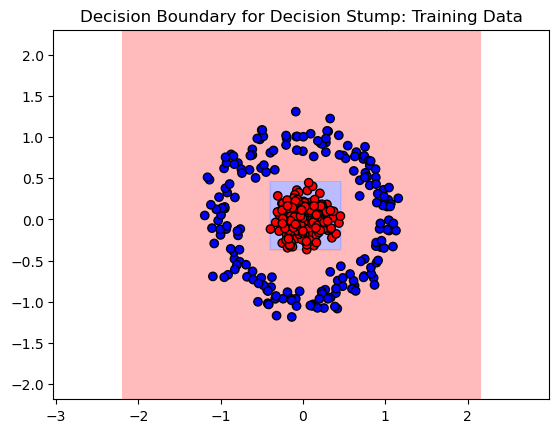

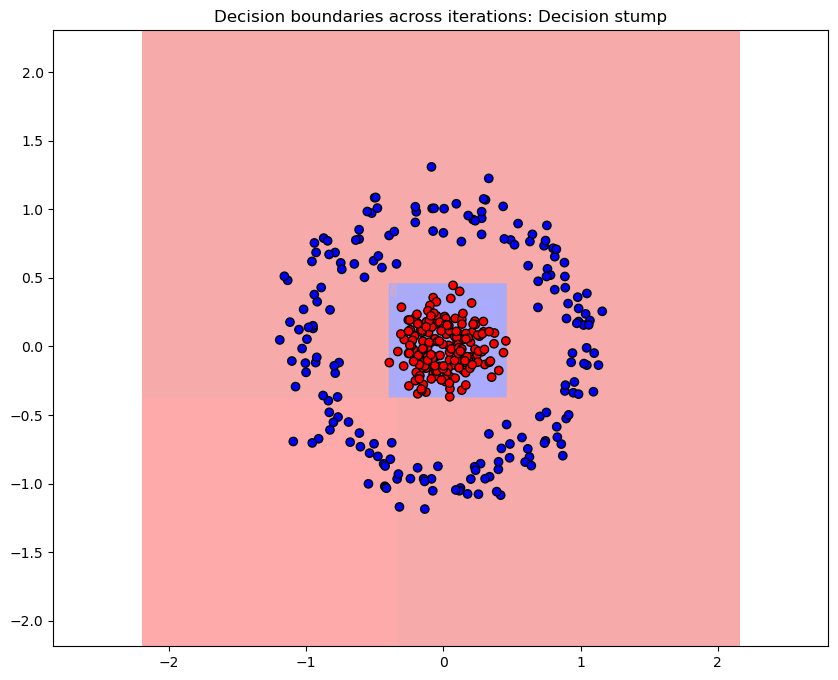

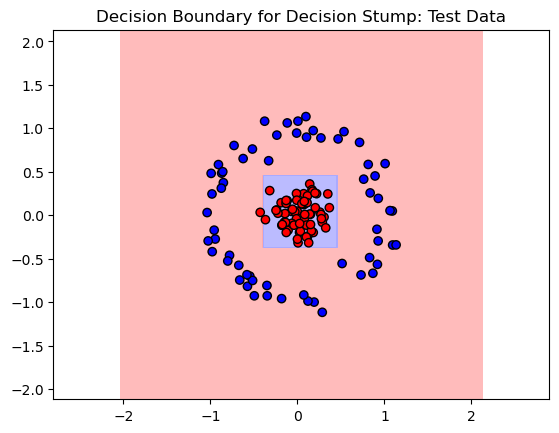

In [10]:
#DECISON STUMP

print("DECISION STUMP")

weak_classifier = DecisionTreeClassifier(max_depth=1)
param_grid = {
    'n_classifiers': [50, 100],
    'eta': [0.5, 1.0],
    'weak_classifier__min_samples_split': [2, 5],
    'weak_classifier__min_samples_leaf': [1, 2]
}

best_params, best_score = AdaBoost.grid_search(X_train, y_train, weak_classifier=weak_classifier, param_grid=param_grid)
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

best_weak_classifier = DecisionTreeClassifier(max_depth=1,
                                              min_samples_split=best_params['weak_classifier__min_samples_split'],
                                              min_samples_leaf=best_params['weak_classifier__min_samples_leaf'])
best_ada_boost = AdaBoost(weak_classifier=best_weak_classifier, n_classifiers=best_params['n_classifiers'], eta=best_params['eta'])
best_ada_boost.fit(X_train, y_train)


train_accuracy = best_ada_boost.accuracy(X_train, y_train)
print("Training Accuracy:", train_accuracy)
test_accuracy = best_ada_boost.accuracy(X_test, y_test)
print("Test Accuracy:", test_accuracy)

best_ada_boost.plot_decision_boundary(X_train, y_train, title="Decision Boundary for Decision Stump: Training Data")
best_ada_boost.plot_iterations(X_train, y_train, title="Decision boundaries across iterations: Decision stump")
best_ada_boost.plot_decision_boundary(X_test, y_test, title="Decision Boundary for Decision Stump: Test Data")

DECISION TREE WITH MAX DEPTH 3
Best Parameters: {'eta': 1.0, 'n_classifiers': 100, 'weak_classifier__min_samples_leaf': 1, 'weak_classifier__min_samples_split': 2}
Best Cross-Validation Score: 0.9946666666666667
Training Accuracy: 1.0
Test Accuracy: 1.0


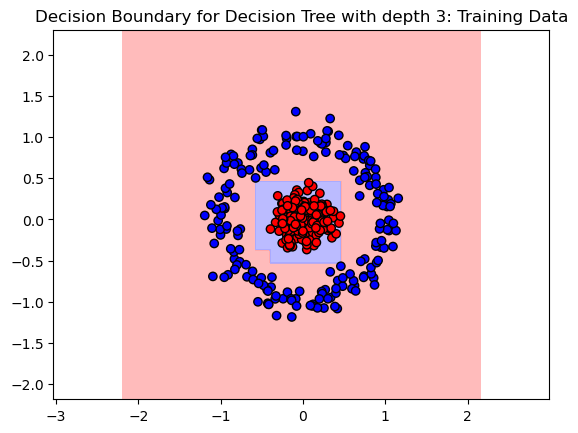

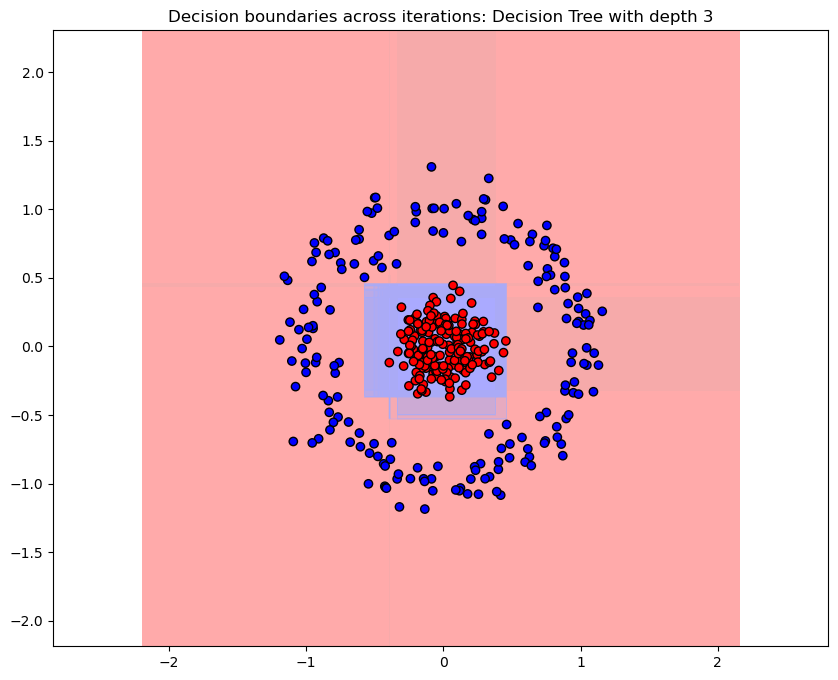

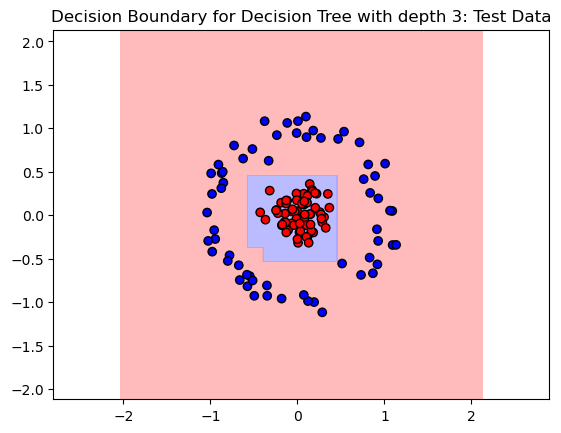

In [11]:
#MAX DEPTH = 3

print("DECISION TREE WITH MAX DEPTH 3")
weak_classifier = DecisionTreeClassifier(max_depth=3)


param_grid = {
    'n_classifiers': [50, 100],
    'eta': [0.5, 1.0],
    'weak_classifier__min_samples_split': [2, 5],
    'weak_classifier__min_samples_leaf': [1, 2]
}

best_params, best_score = AdaBoost.grid_search(X_train, y_train, weak_classifier=weak_classifier, param_grid=param_grid)
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

best_weak_classifier = DecisionTreeClassifier(max_depth=3,
                                              min_samples_split=best_params['weak_classifier__min_samples_split'],
                                              min_samples_leaf=best_params['weak_classifier__min_samples_leaf'])
best_ada_boost = AdaBoost(weak_classifier=best_weak_classifier, n_classifiers=best_params['n_classifiers'], eta=best_params['eta'])
best_ada_boost.fit(X_train, y_train)

train_accuracy = best_ada_boost.accuracy(X_train, y_train)
print("Training Accuracy:", train_accuracy)
test_accuracy = best_ada_boost.accuracy(X_test, y_test)
print("Test Accuracy:", test_accuracy)

best_ada_boost.plot_decision_boundary(X_train, y_train, title="Decision Boundary for Decision Tree with depth 3: Training Data")
best_ada_boost.plot_iterations(X_train, y_train, title="Decision boundaries across iterations: Decision Tree with depth 3")
best_ada_boost.plot_decision_boundary(X_test, y_test, title="Decision Boundary for Decision Tree with depth 3: Test Data")

Best Parameters: {'eta': 1.0, 'n_classifiers': 100, 'weak_classifier__C': 0.1}
Best Cross-Validation Score: 1.0
Training Accuracy: 0.9786666666666667
Test Accuracy: 0.984


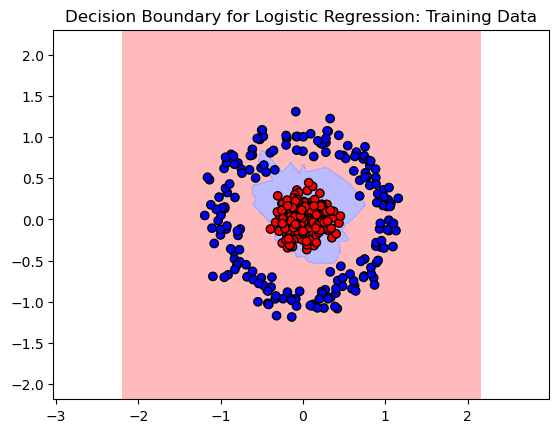

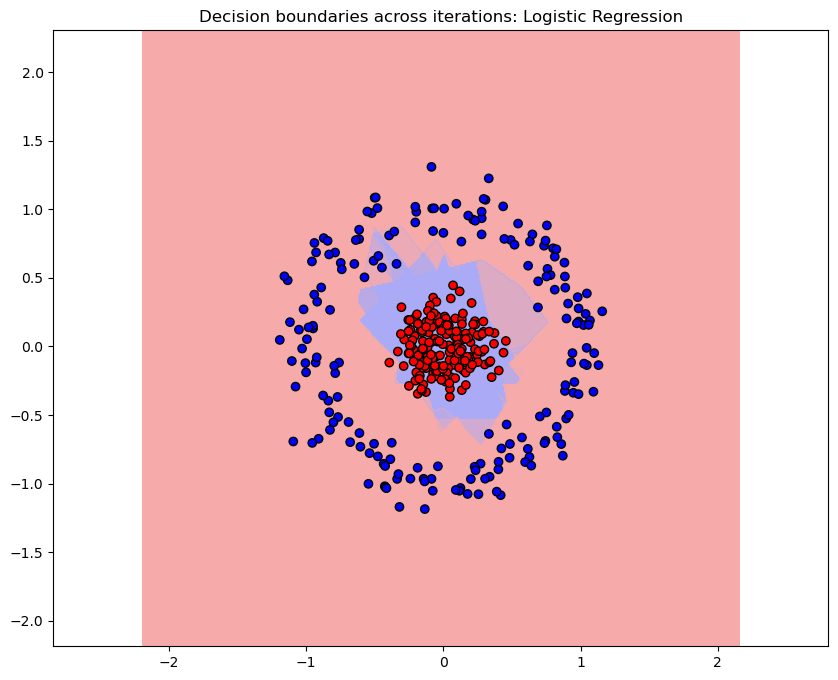

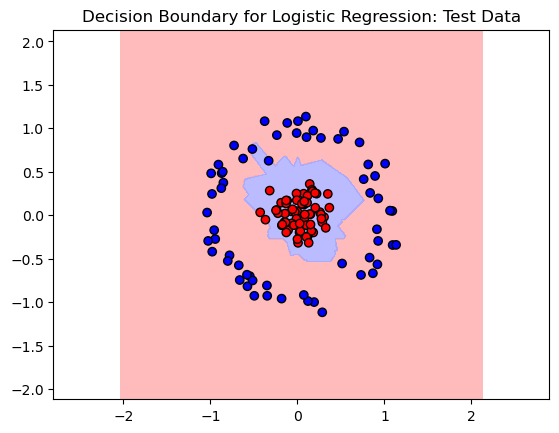

In [12]:
#LOGISTIC REGRESSION
weak_classifier = LogisticRegression(solver='saga',max_iter=200, penalty='l2' )

# Create the parameter grid without prefix
param_grid = {
    'n_classifiers': [50, 100],
    'eta': [0.5, 1.0],
    'weak_classifier__C': [0.01, 0.1, 1],
}


# Perform grid search
best_params, best_score = AdaBoost.grid_search(X_train, y_train, weak_classifier=weak_classifier, param_grid=param_grid)

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

# Fit the AdaBoost model with the best parameters
best_weak_classifier = LogisticRegression(solver='saga', max_iter=200, C=best_params['weak_classifier__C'], penalty='l2')
best_ada_boost = AdaBoost(weak_classifier=best_weak_classifier, n_classifiers=best_params['n_classifiers'], eta=best_params['eta'])
best_ada_boost.fit(X_train, y_train)

# Calculate training accuracy
train_accuracy = best_ada_boost.accuracy(X_train, y_train)
print("Training Accuracy:", train_accuracy)

# Calculate test accuracy
test_accuracy = best_ada_boost.accuracy(X_test, y_test)
print("Test Accuracy:", test_accuracy)

best_ada_boost.plot_decision_boundary(X_train, y_train, title="Decision Boundary for Logistic Regression: Training Data")
best_ada_boost.plot_iterations(X_train, y_train, title="Decision boundaries across iterations: Logistic Regression")
best_ada_boost.plot_decision_boundary(X_test, y_test, title="Decision Boundary for Logistic Regression: Test Data")

In [13]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train = poly.fit_transform(X_train)
X_test = poly.fit_transform(X_test)

LINEAR DISCRIMINANT ANALYSIS
Best Parameters: {'eta': 0.1, 'n_classifiers': 50}
Best Cross-Validation Score: 0.992
Training Accuracy: 0.992
Test Accuracy: 0.992


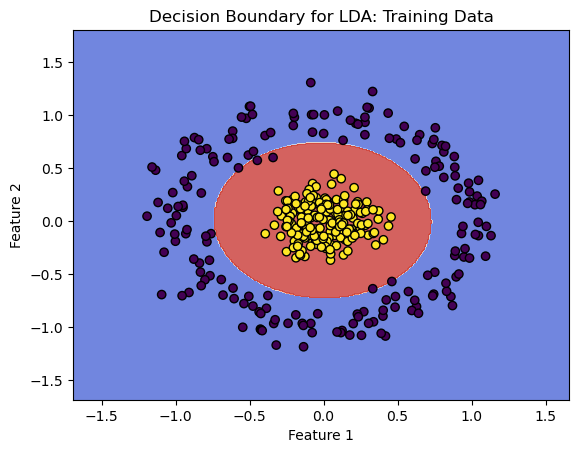

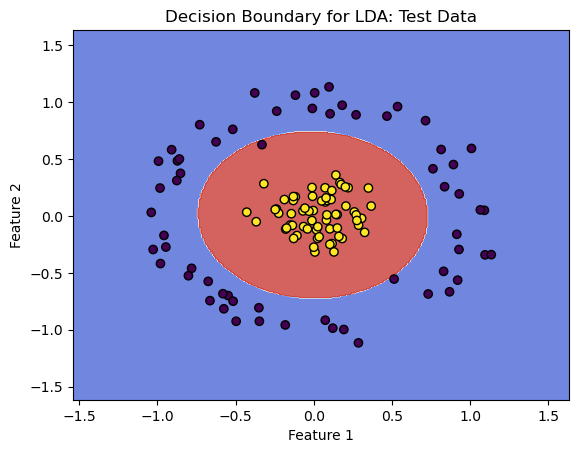

In [14]:
#LDA

print("LINEAR DISCRIMINANT ANALYSIS")
weak_classifier = LDA()

param_grid = {
    'n_classifiers': [50, 100, 200],
    'eta': [0.1, 0.5, 1.0, 1.5]
}


best_params, best_score = AdaBoost.grid_search(X_train, y_train, weak_classifier=weak_classifier, param_grid=param_grid)
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

best_ada_boost = AdaBoost(weak_classifier=LDA(), n_classifiers=best_params['n_classifiers'], eta=best_params['eta'])
best_ada_boost.fit(X_train, y_train)

train_accuracy = best_ada_boost.accuracy(X_train, y_train)
print("Training Accuracy:", train_accuracy)
test_accuracy = best_ada_boost.accuracy(X_test, y_test)
print("Test Accuracy:", test_accuracy)


best_ada_boost.plot_decision_boundary_poly(X_train, y_train, poly, title="Decision Boundary for LDA: Training Data")
best_ada_boost.plot_decision_boundary_poly(X_test, y_test, poly, title="Decision Boundary for LDA: Test Data")

LINEAR SVC
Best Parameters: {'eta': 0.1, 'n_classifiers': 50}
Best Cross-Validation Score: 1.0
Training Accuracy: 1.0
Test Accuracy: 1.0


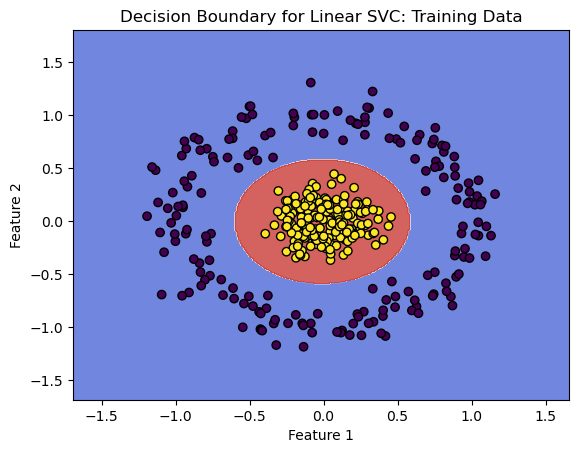

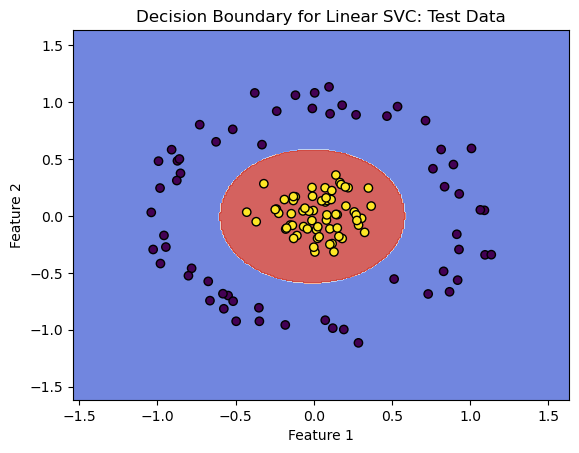

In [15]:
#Linear SVC

print("LINEAR SVC")
weak_classifier = LinearSVC()

param_grid = {
    'n_classifiers': [50, 100, 200],
    'eta': [0.1, 0.5, 1.0, 1.5]
}

best_params, best_score = AdaBoost.grid_search(X_train, y_train, weak_classifier=weak_classifier, param_grid=param_grid)
print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

best_ada_boost = AdaBoost(weak_classifier=LinearSVC(), n_classifiers=best_params['n_classifiers'], eta=best_params['eta'])
best_ada_boost.fit(X_train, y_train)

train_accuracy = best_ada_boost.accuracy(X_train, y_train)
print("Training Accuracy:", train_accuracy)
test_accuracy = best_ada_boost.accuracy(X_test, y_test)
print("Test Accuracy:", test_accuracy)

best_ada_boost.plot_decision_boundary_poly(X_train, y_train, poly, title="Decision Boundary for Linear SVC: Training Data")
best_ada_boost.plot_decision_boundary_poly(X_test, y_test, poly, title="Decision Boundary for Linear SVC: Test Data")